# **Sales Forcasting and Demand Predication - Product Annual Sales**

## **Objective**

### In this project, we aim to develop a machine learning model to predict monthly sales for individual products. This predictive model will assist in optimizing stock levels, ensuring adequate inventory to meet demand while minimizing overstocking and associated costs.

In [4]:
# Gearing up!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

data = pd.read_csv(r"E:\DEPI\Technical\DEPI\Graduation_Project\Sales-Forecasting-and-Demand-Prediction\Dataset\stores_sales_forecasting.csv",  encoding='latin1')
sales_df = pd.DataFrame(data)

sales_df.head() # test


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [29]:
sales_df.Country.value_counts()
sales_df.Category.value_counts()
sales_df.Segment.value_counts()



Segment
Consumer       1113
Corporate       646
Home Office     362
Name: count, dtype: int64

## **Data Cleaning**

In [30]:
sales_df.drop(columns=["Row ID", "Order ID", "Customer ID", "Customer Name", "Product ID", "Postal Code", "Country", "Category", "Discount", "Profit"], inplace=True)
sales_df.head()

,Order Date,Ship Date,Ship Mode,Segment,City,State,Region,Sub-Category,Product Name,Sales,Quantity
0,11/8/2016,11/11/2016,Second Class,Consumer,Henderson,Kentucky,South,Bookcases,Bush Somerset Collection Bookcase,261.9600,2
1,11/8/2016,11/11/2016,Second Class,Consumer,Henderson,Kentucky,South,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3
2,10/11/2015,10/18/2015,Standard Class,Consumer,Fort Lauderdale,Florida,South,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5
3,6/9/2014,6/14/2014,Standard Class,Consumer,Los Angeles,California,West,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7
4,6/9/2014,6/14/2014,Standard Class,Consumer,Los Angeles,California,West,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9


## **Feature Engneering**

In [31]:
sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"], format="%m/%d/%Y", errors="coerce")
sales_df["Ship Date"] = pd.to_datetime(sales_df["Ship Date"], format="%m/%d/%Y", errors="coerce")

In [32]:
sales_df["Order_Year"] = sales_df["Order Date"].dt.year
sales_df["Order_Month"] = sales_df["Order Date"].dt.month

# Dropping original date columns as no need for that now
sales_df.drop(columns = ["Order Date", "Ship Date"],inplace=True)

In [ ]:
sales_df.head()
sales_df.drop(columns=["Quantity"])

Order_Year
2017    686
2016    562
2015    452
2014    421
Name: count, dtype: int64

In [34]:
aggregated_data = sales_df.groupby([
    'Product Name', 'City', 'Region', 'Order_Year', 'Order_Month'
]).agg({
    'Sales': 'sum'
}).reset_index()

aggregated_data.head()

,Product Name,City,Region,Order_Year,Order_Month,Sales
0,12-1/2 Diameter Round Wall Clock,Chicago,Central,2017,6,23.976
1,12-1/2 Diameter Round Wall Clock,Corpus Christi,Central,2014,12,39.960
2,12-1/2 Diameter Round Wall Clock,Harrisonburg,South,2015,11,39.960
3,12-1/2 Diameter Round Wall Clock,Houston,Central,2014,12,23.976
4,12-1/2 Diameter Round Wall Clock,Los Angeles,West,2015,12,79.920


In [35]:
one_hot_cols = ["Region"]
aggregated_data = pd.get_dummies(aggregated_data, columns=one_hot_cols, drop_first=True)

In [36]:
# Get the top 10 most frequent cities
top_cities = sales_df["City"].value_counts().nlargest(10).index

# Create a new column with 'Other' for non-top cities
aggregated_data["City_Grouped"] = aggregated_data["City"].apply(lambda x: x if x in top_cities else "Other")

# One-hot encode the new grouped city feature
aggregated_data = pd.get_dummies(aggregated_data, columns=["City_Grouped"], drop_first=True)

# Drop the original 'City' column to avoid redundancy
aggregated_data.drop(columns=["City"], inplace=True)

aggregated_data.head()



,Product Name,Order_Year,Order_Month,Sales,Region_East,Region_South,Region_West,City_Grouped_Columbus,City_Grouped_Detroit,City_Grouped_Houston,City_Grouped_Los Angeles,City_Grouped_New York City,City_Grouped_Other,City_Grouped_Philadelphia,City_Grouped_San Diego,City_Grouped_San Francisco,City_Grouped_Seattle
0,12-1/2 Diameter Round Wall Clock,2017,6,23.976,False,False,False,False,False,False,False,False,False,False,False,False,False
1,12-1/2 Diameter Round Wall Clock,2014,12,39.960,False,False,False,False,False,False,False,False,True,False,False,False,False
2,12-1/2 Diameter Round Wall Clock,2015,11,39.960,False,True,False,False,False,False,False,False,True,False,False,False,False
3,12-1/2 Diameter Round Wall Clock,2014,12,23.976,False,False,False,False,False,True,False,False,False,False,False,False,False
4,12-1/2 Diameter Round Wall Clock,2015,12,79.920,False,False,True,False,False,False,True,False,False,False,False,False,False


In [39]:
from sklearn.preprocessing import LabelEncoder

state_encoder = LabelEncoder()
aggregated_data["Pname"] = state_encoder.fit_transform(aggregated_data["Product Name"])
aggregated_data.drop(columns=["Product Name"], inplace=True)

aggregated_data.head()


,Order_Year,Order_Month,Sales,Region_East,Region_South,Region_West,City_Grouped_Columbus,City_Grouped_Detroit,City_Grouped_Houston,City_Grouped_Los Angeles,City_Grouped_New York City,City_Grouped_Other,City_Grouped_Philadelphia,City_Grouped_San Diego,City_Grouped_San Francisco,City_Grouped_Seattle,Pname
0,2017,6,23.976,False,False,False,False,False,False,False,False,False,False,False,False,False,0
1,2014,12,39.960,False,False,False,False,False,False,False,False,True,False,False,False,False,0
2,2015,11,39.960,False,True,False,False,False,False,False,False,True,False,False,False,False,0
3,2014,12,23.976,False,False,False,False,False,True,False,False,False,False,False,False,False,0
4,2015,12,79.920,False,False,True,False,False,False,True,False,False,False,False,False,False,0


In [40]:
aggregated_data.to_csv('encoded_agg_NewData.csv', index=False)

## **Modelling**

In [5]:
encoded_sales_df = pd.read_csv(r"E:\DEPI\Technical\DEPI\Graduation_Project\Sales-Forecasting-and-Demand-Prediction\Dataset\encoded_agg_NewData.csv")

encoded_sales_df.head()

,Order_Year,Order_Month,Sales,Region_East,Region_South,Region_West,City_Grouped_Columbus,City_Grouped_Detroit,City_Grouped_Houston,City_Grouped_Los Angeles,City_Grouped_New York City,City_Grouped_Other,City_Grouped_Philadelphia,City_Grouped_San Diego,City_Grouped_San Francisco,City_Grouped_Seattle,Pname
0,2017,6,23.976,False,False,False,False,False,False,False,False,False,False,False,False,False,0
1,2014,12,39.960,False,False,False,False,False,False,False,False,True,False,False,False,False,0
2,2015,11,39.960,False,True,False,False,False,False,False,False,True,False,False,False,False,0
3,2014,12,23.976,False,False,False,False,False,True,False,False,False,False,False,False,False,0
4,2015,12,79.920,False,False,True,False,False,False,True,False,False,False,False,False,False,0


### **Data Splitting**

In [6]:
from sklearn.model_selection import train_test_split
# Statistical Analysis
from scipy.stats import ttest_ind
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_log_error
# Modelling
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
import pickle

# data splitting

train_set = encoded_sales_df.loc[encoded_sales_df['Order_Year'].isin([2014, 2015, 2016])]
eval_set = encoded_sales_df.loc[encoded_sales_df['Order_Year'] == 2017]

In [7]:
# Separate the target variable and features for training and testing
X_train = train_set.drop('Sales', axis=1)
y_train = train_set['Sales'] 


X_eval = eval_set.drop('Sales', axis=1)  
y_eval = eval_set['Sales']

In [8]:
# Initialize the results dataframe
results_df = pd.DataFrame(columns=['Model', 'RMSLE', 'RMSE', 'MSE', 'MAE'])

### **Linear Regression**

In [9]:
# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_eval)

# Calculate metrics
lr_mse = mean_squared_error(y_eval, lr_predictions)
lr_mae = mean_absolute_error(y_eval, lr_predictions)

# Apply the absolute value function to both y_eval and lr_predictions
y_eval_abs = abs(y_eval)
lr_predictions_abs = abs(lr_predictions)

# Calculate the Root Mean Squared Logarithmic Error (RMSLE)
lr_rmsle = np.sqrt(mean_squared_log_error(y_eval_abs, lr_predictions_abs))

# Create a DataFrame to store results for Linear Regression
results_lr = pd.DataFrame({'Model': ['Linear Regression'],
                            'RMSLE': [lr_rmsle],
                            'RMSE': [np.sqrt(lr_mse)],
                            'MSE': [lr_mse],
                            'MAE': [lr_mae]}).round(2)

# Print the results_lr dataframe
print(results_lr)

# Add the results to the overall results DataFrame
print(lr_model.score(X_train,y_train))
print(lr_model.score(X_eval,y_eval))

               Model  RMSLE    RMSE        MSE     MAE
0  Linear Regression   1.72  451.76  204085.59  305.39
0.013349769749689377
0.0012674753693875385


### **Random Forest**

In [10]:
# Random Forest Regression Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_eval)

# Calculate metrics
rf_mse = mean_squared_error(y_eval, rf_predictions)
rf_mae = mean_absolute_error(y_eval, rf_predictions)

# Apply the absolute value function to both y_eval and rf_predictions
y_eval_abs = abs(y_eval)
rf_predictions_abs = abs(rf_predictions)

# Calculate the Root Mean Squared Logarithmic Error (RMSLE)
rf_rmsle = np.sqrt(mean_squared_log_error(y_eval_abs, rf_predictions_abs))

# Create a DataFrame to store results for Random Forest
results_rf = pd.DataFrame({'Model': ['Random Forest'],
                            'RMSLE': [rf_rmsle],
                            'RMSE': [np.sqrt(rf_mse)],
                            'MSE': [rf_mse],
                            'MAE': [rf_mae]}).round(2)

# Print the results_rf dataframe
results_rf

print(results_rf)

# Add the results to the overall results DataFrame
print(rf_model.score(X_train,y_train))
print(rf_model.score(X_eval,y_eval))

           Model  RMSLE    RMSE        MSE    MAE
0  Random Forest   1.08  378.27  143091.03  226.7
0.9053095851467075
0.29975621976837463


### **XGBOOST**

In [11]:
from xgboost import XGBRegressor

# 🚀 XGBoost Model
xgb_model = XGBRegressor(
    random_state=42, n_estimators=100, learning_rate=0.1, max_depth=6
)

# ✅ Train and Predict
xgb_model.fit(X_train, y_train)
xgb_predictions = np.maximum(0, xgb_model.predict(X_eval))  # Avoid negatives

# 📊 Evaluate
xgb_rmsle = np.sqrt(mean_squared_log_error(abs(y_eval), abs(xgb_predictions)))
xgb_rmse = np.sqrt(mean_squared_error(y_eval, xgb_predictions))
xgb_mse = mean_squared_error(y_eval, xgb_predictions)
xgb_mae = mean_absolute_error(y_eval, xgb_predictions)

# 📋 Save results to DataFrame
results_xgb = pd.DataFrame({
    'Model': ['XGBoost'],
    'RMSLE': [xgb_rmsle],
    'RMSE': [xgb_rmse],
    'MSE': [xgb_mse],
    'MAE': [xgb_mae]
}).round(2)


#----------------------------------------------------------------------------------------------------------------------------------------

# Print the results
print(results_xgb)

# Add the results to the overall results DataFrame
print(xgb_model.score(X_train,y_train))
print(xgb_model.score(X_eval,y_eval))

     Model  RMSLE    RMSE        MSE     MAE
0  XGBoost   1.27  396.33  157080.36  244.09
0.809867105051898
0.23126429916337166


## **Log Scale**

                        Model  RMSLE    RMSE        MSE     MAE
0  Random Forest (Log Target)   0.85  359.49  129230.98  186.78
Train R² (log-scale): 0.953542407646923
Test R² (log-scale): 0.6549526074476525


### **Random Forest**

                        Model  RMSLE    RMSE        MSE     MAE
0  Random Forest (Log Target)   0.85  359.49  129230.98  186.78
Train R² (log-scale): 0.953542407646923
Test R² (log-scale): 0.6549526074476525


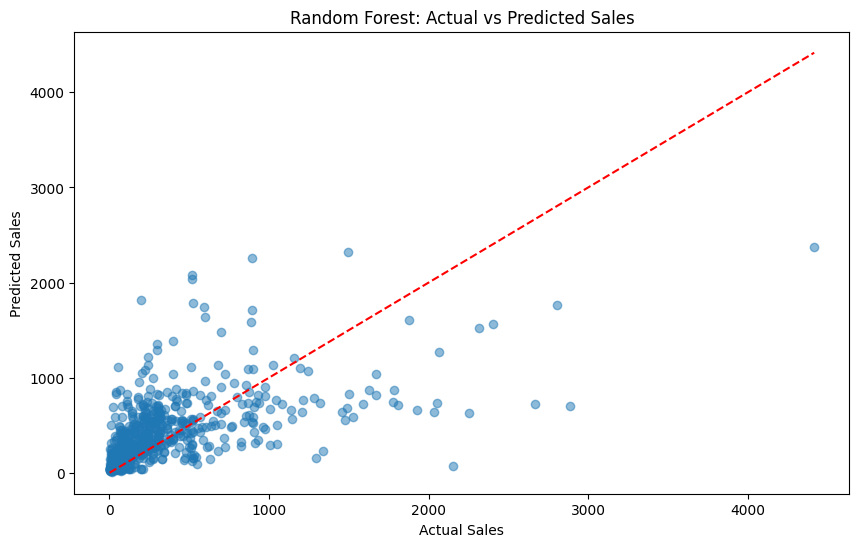

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
# ----- 1. Data Preparation -----
# Split the data by year
train_set = encoded_sales_df.loc[encoded_sales_df['Order_Year'].isin([2014, 2015, 2016])]
eval_set = encoded_sales_df.loc[encoded_sales_df['Order_Year'] == 2017]

# Separate features and target
X_train = train_set.drop('Sales', axis=1)
y_train = train_set['Sales']

X_eval = eval_set.drop('Sales', axis=1)
y_eval = eval_set['Sales']

# Make sure Sales is non-negative for log1p
assert (y_train >= 0).all(), "y_train contains negative values"
assert (y_eval >= 0).all(), "y_eval contains negative values"

# ----- 2. Log Transformation of Target -----
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_eval)



# ----- 3. Train Random Forest -----
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train_log)

# ----- 4. Predict and Inverse Transform -----
y_pred_log = rf_model.predict(X_eval)

# Safety clip for large values
y_pred_log = np.clip(y_pred_log, a_min=None, a_max=700)
y_test_log = np.clip(y_test_log, a_min=None, a_max=700)

y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test_log)

# ----- 5. Evaluate Performance -----
rf_mse = mean_squared_error(y_test_real, y_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test_real, y_pred)
rf_rmsle = np.sqrt(mean_squared_log_error(y_test_real, np.maximum(0, y_pred)))  # RMSLE needs non-negative preds

results_rf = pd.DataFrame({
    'Model': ['Random Forest (Log Target)'],
    'RMSLE': [rf_rmsle],
    'RMSE': [rf_rmse],
    'MSE': [rf_mse],
    'MAE': [rf_mae]
}).round(2)

print(results_rf)

# ----- 6. R² Scores on Log Scale -----
print("Train R² (log-scale):", rf_model.score(X_train, y_train_log))
print("Test R² (log-scale):", rf_model.score(X_eval, y_test_log))

plt.figure(figsize=(10, 6))
plt.scatter(y_eval, rf_predictions, alpha=0.5)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Random Forest: Actual vs Predicted Sales")
plt.plot([y_eval.min(), y_eval.max()], [y_eval.min(), y_eval.max()], 'r--')
plt.show()


NameError: name 'y_eval' is not defined

<Figure size 1000x600 with 0 Axes>

### **XGBOOST**

                  Model  RMSLE   RMSE        MSE     MAE
0  XGBoost (Log Target)   0.91  380.3  144630.31  193.18
Train R²: 0.8537651922691791
Test R²: 0.5995716660208739


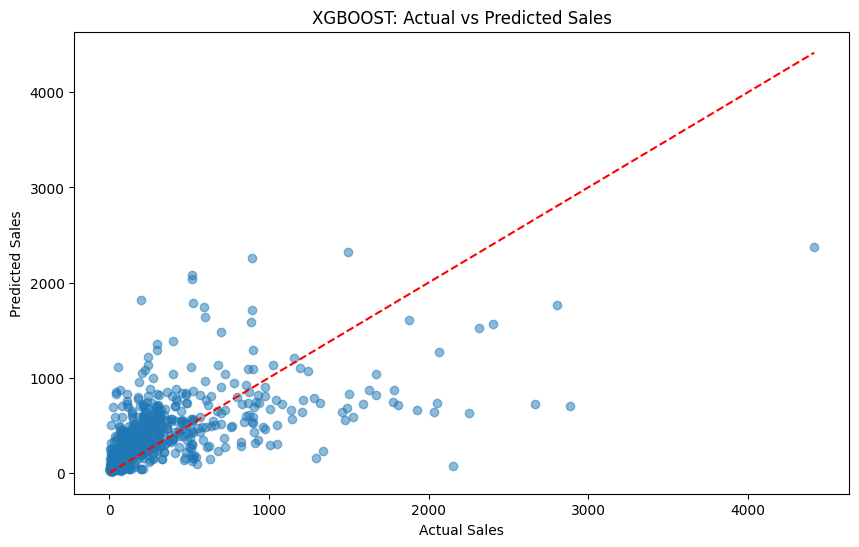

In [24]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_log_error
import numpy as np
import pandas as pd

# ----- 1. Apply log1p transformation to y_train and y_eval -----
y_train_log = np.log1p(y_train)   # log(1 + y)
y_test_log = np.log1p(y_eval)



from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# ----- 2. Train the XGBoost Regressor on log-transformed target -----
xgb_model = XGBRegressor(random_state=42, n_estimators=1000, learning_rate=0.01, max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8)
xgb_model.fit(X_train, y_train_log)

# ----- 3. Predict on the test data (in log scale) -----
y_pred_log = xgb_model.predict(X_eval)

# ----- 4. Inverse the transformation to get real-scale predictions -----
y_pred = np.expm1(y_pred_log)  # inverse of log1p
y_test_real = np.expm1(y_test_log)

# ----- 5. Evaluate model performance -----
xgb_mse = mean_squared_error(y_eval, y_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae = mean_absolute_error(y_eval, y_pred)
xgb_rmsle = np.sqrt(mean_squared_log_error(y_eval, np.maximum(0, y_pred)))  # clamp negatives if any

# ----- 6. Print results -----
results_xgb = pd.DataFrame({
    'Model': ['XGBoost (Log Target)'],
    'RMSLE': [xgb_rmsle],
    'RMSE': [xgb_rmse],
    'MSE': [xgb_mse],
    'MAE': [xgb_mae]
}).round(2)

print(results_xgb)

# ----- 7. R² Scores -----
print("Train R²:", xgb_model.score(X_train, y_train_log))  # still log-scale
print("Test R²:", xgb_model.score(X_eval, y_test_log))

plt.figure(figsize=(10, 6))
plt.scatter(y_eval, rf_predictions, alpha=0.5)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("XGBOOST: Actual vs Predicted Sales")
plt.plot([y_eval.min(), y_eval.max()], [y_eval.min(), y_eval.max()], 'r--')
plt.show()


In [65]:
encoded_sales_df[encoded_sales_df['Sales'] < 0]

,Order_Year,Order_Month,Sales,Region_East,Region_South,Region_West,City_Grouped_Columbus,City_Grouped_Detroit,City_Grouped_Houston,City_Grouped_Los Angeles,City_Grouped_New York City,City_Grouped_Other,City_Grouped_Philadelphia,City_Grouped_San Diego,City_Grouped_San Francisco,City_Grouped_Seattle,Pname


In [30]:
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

# Use already loaded encoded_sales_df, X_train, y_train, X_eval, y_eval

# Log-transform the targets
y_train_log = np.log1p(y_train)
y_eval_log = np.log1p(y_eval)

# Base models
rf_model = RandomForestRegressor(n_estimators=500, max_depth=20, random_state=42)
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)

# Meta-model
meta_model = LinearRegression()

# Stacking Regressor (fit on log-transformed targets)
stacked_model = StackingRegressor(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    final_estimator=meta_model,
    passthrough=False,
    n_jobs=-1
)

stacked_model.fit(X_train, y_train_log)

# Predict in log space, then inverse-transform
y_pred_log = stacked_model.predict(X_eval)
y_pred = np.expm1(y_pred_log)
y_eval_real = y_eval  # already in original scale

# Metrics
mse = mean_squared_error(y_eval_real, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_eval_real, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_eval_real, np.maximum(0, y_pred)))

print(f"RMSLE: {rmsle:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# Optional: R² on log-scale
print("Train R² (log):", stacked_model.score(X_train, y_train_log))
print("Test R² (log):", stacked_model.score(X_eval, y_eval_log))


RMSLE: 1.3362
RMSE: 471.08
MAE: 243.08
Train R² (log): 0.20412456933332446
Test R² (log): 0.14447975886313302


## **Stock Optimization**

### Classical Knapsack Problem 

In [ ]:
# need the stock capacity!!!